<a href="https://colab.research.google.com/github/jptrainor4-glitch/Data-Analytics/blob/main/Bars_data_cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [124]:
'''
Which parts of the Melbourne CBD have strong evening foot traffic but relatively few bar and pub seats,
making them good spots for a new venue?


Convert columns into more appropriate data types.
Clean Trading name format
Dropped Location column
Checked scope of Property ID in terms of Long and Lat and decided if data was relevant and accurate
Created column indicating orginal data missing values
Filled missing values in Long and Lat with mean of identical Property ID
Measured open and closes of venues, less relevant but good for trend identification
Histogram on venue seats to identify clusters and outliers
Investigated outliers and semi manually flagged outliers

'''

'\nWhich parts of the Melbourne CBD have strong evening foot traffic but relatively few bar and pub seats,\nmaking them good spots for a new venue?\n'

In [125]:
import pandas as pd
import os
from google.colab import files, drive
import matplotlib.pyplot as plt
import shutil # Import shutil for file operations

drive.mount('/content/drive')                                   #Mount Google Drive

drive_folder = '/content/drive/MyDrive/colab_data/'             # Define the path where you want to save the file in Google Drive

os.makedirs(drive_folder, exist_ok=True)                        # Create the folder if it doesn't exist

expected_filename = 'bars-and-pubs-with-patron-capacity.csv'
drive_filepath = os.path.join(drive_folder, expected_filename)


if os.path.exists(drive_filepath):                              # Check if the file already exists in Google Drive
    print(f"Loading '{expected_filename}' from Google Drive...")
    df = pd.read_csv(drive_filepath)
else:
    print(f"'{expected_filename}' not found in Google Drive. Please upload it.")
    uploaded = files.upload()

    if uploaded:
        filename = list(uploaded.keys())[0]
        df = pd.read_csv(filename)

        shutil.copyfile(filename, drive_filepath)              # Save the uploaded file to Google Drive for future use
        os.remove(filename)                                    # Remove the temporary uploaded file
        print(f"'{filename}' uploaded and saved to Google Drive at '{drive_filepath}'.")
    else:
        print("No file was uploaded. Creating an empty DataFrame.")
        df = pd.DataFrame()                                    # Create an empty DataFrame if no file is uploaded

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading 'bars-and-pubs-with-patron-capacity.csv' from Google Drive...


In [139]:
#How many rows and columns are there?

'''12 columns, 5304 rows.'''

#What does one row represent? This is the most important question on the list.
#Is it one venue, or something else? Look at the columns and think about why the same bar might show up more than once.
'''One row represents an entry for a specfic venue on a specific census year.
The same bar can show up more than once in the data set as it is recorded year for year.'''


#Which columns are numbers and which are text? Did pandas read them as the right types?

df['Block ID'] = df['Block ID'].astype(str)                     #Convert label information into strings
df['Base property ID'] = df['Base property ID'].astype(str)
df['Property ID'] = df['Property ID'].astype(str)

# Set Trading names to all lower case and strip spaces from front and back of strings
df['Trading name'] = df['Trading name'].str.strip().str.lower()


df.info()

#Where are the missing values, and how many are there?
''' There are 5284 entries for the geographic coordinants, meaning 20 entries are missing this information.'''

#Which years does the data cover, and how many rows are in each year?
print('\n', 'min', df['Census year'].min(), 'max', df['Census year'].max(), '\n')

'''2002 - 2024'''

result = df.groupby('Census year').agg(
    Entry_by_Year=('Census year', 'size'),
    Small_area_count=('CLUE small area', 'nunique')
).reset_index()

print(result, '\n', result.describe())

'''Entries steadly increase through the time period: min - 2002 = 97,
max - 2024 = 304'''

#Is there anything that looks odd, like strange values, duplicates or inconsistent spellings?
df.duplicated(subset=None, keep='first').sum()
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5304 entries, 0 to 5303
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Census year        5304 non-null   int64  
 1   Block ID           5304 non-null   object 
 2   Property ID        5304 non-null   object 
 3   Base property ID   5304 non-null   object 
 4   Building address   5304 non-null   object 
 5   CLUE small area    5304 non-null   object 
 6   Trading name       5304 non-null   object 
 7   Business address   5304 non-null   object 
 8   Number of patrons  5304 non-null   int64  
 9   Longitude          5304 non-null   float64
 10  Latitude           5304 non-null   float64
 11  Missing Value      5304 non-null   bool   
 12  outlier_venue      5304 non-null   bool   
dtypes: bool(2), float64(2), int64(2), object(7)
memory usage: 466.3+ KB

 min 2002 max 2024 

    Census year  Entry_by_Year  Small_area_count
0          2002             9

,0
Census year,0
Block ID,0
Property ID,0
Base property ID,0
Building address,0
CLUE small area,0
Trading name,0
Business address,0
Number of patrons,0
Longitude,0


In [127]:
#Add a missing value column to df.
#Check df for missing values and then further distil into uniquely independent rows

df_missing_rows = df[df.isna().any(axis=1)]                       #Locating rows with missing values and allocating to a new df

df_cleaned = df.dropna().copy()                                   #Creating a new df excluding the missing values

shared_values = df_missing_rows['Property ID'].isin(df_cleaned['Property ID'])    #Comparing the 2 new dfs to see if they share property IDs
false_shared_values = shared_values[~ shared_values]              #Condense shared values down into only False returns, ie: NaN values with a unique Propert ID
print(false_shared_values)

'''
shared_values produces a table which compares the two above df's and creates a boolen.
This determines wether the rows in the missing_rows df share Property ID with rows in the cleaned df.
'''

if len(df_missing_rows) > 0:
  df['Missing Value'] = df.isna().any(axis=1)             #Add a new column to df that marks the missing values rows

print(type(df.iloc[0]['location']))                       #Print what d type the location column is

df = df.drop(columns = ['location'])                      #Drop location columns as both Latitue and Longitude are already containing the information

'''
  Important this column is created before filling the values, as it marks what as been manually altered vs the orginal data.
'''

Series([], Name: Property ID, dtype: bool)
<class 'str'>


'\n  Important this column is created before filling the values, as it marks what as been manually altered vs the orginal data.\n'

In [128]:
# Finding max unique values of various columns given they are grouped together by property ID

def max_p_id(column_name):    #Takes a column name from sorted_by_id, finds the Property ID with the maximum value
                              #in that column, and returns the rows from the original df DataFrame for that Property ID.
    if column_name not in sorted_by_id.columns:
        print(f"Error: Column '{column_name}' not found in sorted_by_id.")
        return None

    max_property_id = sorted_by_id[column_name].idxmax()        # Get the Property ID with the maximum value in the specified column, this could be altered to find the biggest varience amongest min and max values.
    filtered_df = df[df['Property ID'] == max_property_id]      # Filter the original df DataFrame by this Property ID

    return filtered_df


sorted_by_id = df.groupby('Property ID').agg(                     #New data set that groups each row into the same Property ID
    Trade_Name_count = ('Trading name', 'nunique'),               #Using .agg each column is a count of unique values.
    Business_add_count =('Business address', 'nunique'),          #This will highlight how many different values share the same property id for each column
    long_spread = ('Longitude', lambda x: x.max() - x.min()),
    lat_spread = ('Latitude', lambda x: x.max() - x.min()),
    Long_count = ('Longitude', 'nunique'),
    Lat_count = ('Latitude', 'nunique')
)


print(sorted_by_id.describe())                                    #Summerise values

lat_spread_id = max_p_id('lat_spread')
long_spread_id = max_p_id('long_spread')
                                      #Run function to determine the most unique Location values per proprty ID

Long = 88 * (long_spread_id['Longitude'].max() - long_spread_id['Longitude'].min())             #Determine the varience between the max and min location values of given property ID
Lat = 111 * (lat_spread_id['Latitude'].max() - lat_spread_id['Latitude'].min())         #Multipliers are a rough converion from degree into km's



print(Long, Lat)                    #Print final result of max spread respectively for Long and Lat

print(long_spread_id)               #Print df for max spread to investigate address and trading name

'''
This particular result finds the most volitale property ID in terms of Latitude spread,
then finds the meter distibution of the min and max location columns.
These results are used to determine wether or not the spread is too wide to fill in missing values with
the same propert ID.
'''

       Trade_Name_count  Business_add_count   long_spread  lat_spread  \
count        389.000000          389.000000  3.890000e+02  389.000000   
mean           2.149100            2.503856  1.677231e-05    0.000009   
std            2.123356            2.075411  7.198960e-05    0.000050   
min            1.000000            1.000000  0.000000e+00    0.000000   
25%            1.000000            1.000000  2.300001e-08    0.000000   
50%            2.000000            2.000000  9.434000e-06    0.000001   
75%            3.000000            3.000000  9.488000e-06    0.000001   
max           30.000000           23.000000  1.032516e-03    0.000593   

       Long_count   Lat_count  
count  389.000000  389.000000  
mean     2.619537    2.064267  
std      1.257648    1.014576  
min      1.000000    1.000000  
25%      2.000000    1.000000  
50%      2.000000    2.000000  
75%      3.000000    2.000000  
max      9.000000    9.000000  
0.09086140800081921 0.06580746000052073
      Census y

'\nThis particular result finds the most volitale property ID in terms of Latitude spread,\nthen finds the meter distibution of the min and max location columns.\nThese results are used to determine wether or not the spread is too wide to fill in missing values with\nthe same propert ID.\n'

In [129]:
#Fill missing values using mean from rows with matching property IDs.

temp = df.groupby('Property ID').agg(                                           #Set up a temp df to hold Long and Lat means for each unique Property ID
    Long = ('Longitude', 'mean'),
    Lat = ('Latitude', 'mean')
)

print(df['Longitude'].isna().sum(), df['Latitude'].isna().sum())                #Check missing values from each column before

df['Longitude'] = df['Longitude'].fillna(df['Property ID'].map(temp['Long']))   #Assign averages to each column using .fillna and .map
df['Latitude'] = df['Latitude'].fillna(df['Property ID'].map(temp['Lat']))

print(df['Longitude'].isna().sum(), df['Latitude'].isna().sum())                #Check missing values after

'''
Filling in the missing value Longitude and Latitude gives a more complete dataset.
While the filled values are a mean average of rows with the same property ID,
investigation about shows that variances are not more than around 9 meters in distance.
'''


20 20
0 0


'\nFilling in the missing value Longitude and Latitude gives a more complete dataset.\nWhile the filled values are a mean average of rows with the same property ID,\ninvestigation about shows that variances are not more than around 9 meters in distance.\n'

In [130]:
# Work out arrivals and departures per year each property ID.

filtered_df = df.groupby('Property ID').agg(             #Filter df by when each Property ID name appears and disappears
    Open = ('Census year', 'min'),
    Close = ('Census year', 'max')
)

open_counts = filtered_df['Open'].value_counts().sort_index()     #Count how many venues opened/ closed per year
close_counts = filtered_df['Close'].value_counts().sort_index()   #Sort index so both open and close counts allign

combined_counts = pd.DataFrame({                          #Place both counts in the same df to veiw next to each other
    'Opened': open_counts,
    'Closed': close_counts
}).fillna(0).astype(int)

display(combined_counts)

'''
Venue behaviour is anaylsised to determine any outliers or
abnormal behavious in venues opening and closing trends.
This analysis can be further distilled by area to gain further detail on
estimated longevity of a venues life in specific areas.
'''

,Opened,Closed
2002,94,0
2003,6,2
2004,26,3
2005,18,2
2006,17,2
2007,13,9
2008,27,4
2009,16,0
2010,14,6
2011,19,8


'\nVenue behaviour is anaylsised to determine any outliers or\nabnormal behavious in venues opening and closing trends.\nThis analysis can be further distilled by area to gain further detail on\nestimated longevity of a venues life in specific areas.\n'

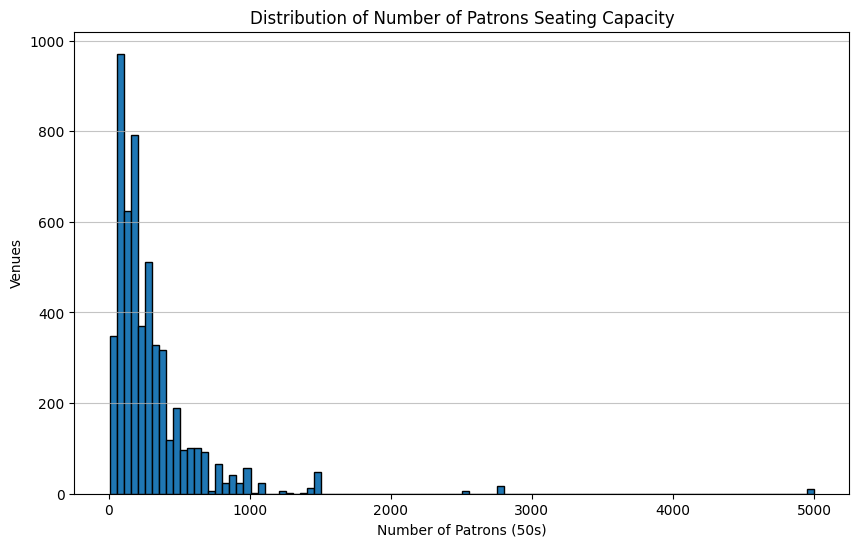

'\nThis graph shows a number of outliers in terms of seating capacity.\nITs a great visual to demostrate the majority of venues of a seating capacity between 50-250px.\n'

In [131]:
import matplotlib.pyplot as plt

# Create a histogram for 'Number of patrons'
plt.figure(figsize=(10, 6))
plt.hist(df['Number of patrons'].dropna(), bins=100, edgecolor='black')
plt.title('Distribution of Number of Patrons Seating Capacity')
plt.xlabel('Number of Patrons (50s)')
plt.ylabel('Venues')
plt.grid(axis='y', alpha=0.75)
plt.show()

'''
This graph shows a number of outliers in terms of seating capacity.
ITs a great visual to demostrate the majority of venues of a seating capacity between 50-250px.
'''

In [132]:
#Check each property IDs seating capacity and displays table to search for outliers or error.

patrons_by_property = df.groupby('Property ID')['Number of patrons'].agg(['min', 'max', 'median', 'count'])
#Creat a df grouping rows together by property id and then summerising seating information over the time scale of the data set


sorted_grouped_patrons = patrons_by_property.sort_values(by='max', ascending=False) #Sort new df by seat capacity

display(sorted_grouped_patrons)

print(df[df['Property ID'] == '558180'])

'''
Looking for outliers with the seats per venue, a table is displayed to determine
min and max seats then compare them against the median for that venue over the number of years.
As the grouping factor of a venue is property ID, a few different trading names or venues can
be included in the one row of the patrons by property df.
Each property ID is than indexed manually to see that the summery includes different trading names
under the same year, thus different capacity's for different venues are recorded under the same
row.
'''

max_seats_property_ids = list(sorted_grouped_patrons.head(20).index)

# Filter df to include only the rows with Property IDs from max_seats_property_ids
filtered_df = df[df['Property ID'].isin(max_seats_property_ids)]

#Display a table which can be manually sorted for actual venues vs actual outliers within the data
display(filtered_df[['Property ID', 'Trading name','Building address', 'Number of patrons', 'Census year']].sort_values(by=['Property ID', 'Census year']))


'''
ignore: ['110266', '606461', '104020', '108967', '110988', '110542', '601809', '623559', '558180', '108068']
'558180' - Marvel Stadium - stadium
'601809' - the waterfront room - event space BUT bcm bar & balcony is a venue
'606461' - batman's hill on collins hotel - hotel
'108967' - batman's hill on collins hotel - hotel
'104020' - 	forum theatre bar - stadium
'110266' - 	spotless services - stadium
'110988' - Atlantic south warf function center - function center
'110542' -Convention center
'623559' - pan pacific - hotel
'108068' - citiclub on queen - hotel

keep: ['103198', '110537', '101212', '108068']
'101212' - charltons entertainment complex / roxanne bar - venue
'108068' - cq bar - venue
'110537' -	the boatbuilders yard - venue
'103198' - Oche Melbourne - venue
'''

,min,max,median,count
Property ID,,,,
558180,70,5000,250.0,66
110266,2545,2800,2800.0,23
108068,60,1505,200.0,58
101212,450,1500,1500.0,14
606461,1500,1500,1500.0,16
...,...,...,...,...
630705,25,25,25.0,2
110690,20,20,20.0,4
106944,12,12,12.0,2


      Census year Block ID Property ID Base property ID  \
417          2009     1103      558180           558180   
587          2011     1103      558180           558180   
588          2011     1103      558180           558180   
663          2012     1103      558180           558180   
664          2012     1103      558180           558180   
...           ...      ...         ...              ...   
4790         2019     1103      558180           558180   
4791         2019     1103      558180           558180   
4889         2020     1103      558180           558180   
5096         2022     1103      558180           558180   
5298         2024     1103      558180           558180   

                                       Building address CLUE small area  \
417            122-148 Harbour Esplanade DOCKLANDS 3008       Docklands   
587            122-148 Harbour Esplanade DOCKLANDS 3008       Docklands   
588            122-148 Harbour Esplanade DOCKLANDS 3008       Dock

,Property ID,Trading name,Building address,Number of patrons,Census year
2275,101212,roxanne parlour,152-158 Bourke Street MELBOURNE 3000,450,2011
4092,101212,roxanne parlour,152-158 Bourke Street MELBOURNE 3000,450,2012
2449,101212,charltons entertainment complex / roxanne bar,152-158 Bourke Street MELBOURNE 3000,1500,2013
779,101212,charltons entertainment complex / roxanne bar,152-158 Bourke Street MELBOURNE 3000,1500,2014
4373,101212,charltons entertainment complex / roxanne bar,152-158 Bourke Street MELBOURNE 3000,1500,2015
...,...,...,...,...,...
4892,640970,hightail,14-24 Batmans Hill Drive DOCKLANDS VIC 3008,900,2020
1450,640970,hightail,14-24 Batmans Hill Drive DOCKLANDS VIC 3008,900,2021
5098,640970,hightail,14-24 Batmans Hill Drive DOCKLANDS VIC 3008,900,2022
3403,640970,hightail,14-24 Batmans Hill Drive DOCKLANDS VIC 3008,950,2023


"\nignore: ['110266', '606461', '104020', '108967', '110988', '110542', '601809', '623559', '558180', '108068']\n'558180' - Marvel Stadium - stadium\n'601809' - the waterfront room - event space BUT bcm bar & balcony is a venue\n'606461' - batman's hill on collins hotel - hotel\n'108967' - batman's hill on collins hotel - hotel\n'104020' - \tforum theatre bar - stadium\n'110266' - \tspotless services - stadium\n'110988' - Atlantic south warf function center - function center\n'110542' -Convention center\n'623559' - pan pacific - hotel\n'108068' - citiclub on queen - hotel\n\nkeep: ['103198', '110537', '101212', '108068']\n'101212' - charltons entertainment complex / roxanne bar - venue\n'108068' - cq bar - venue\n'110537' -\tthe boatbuilders yard - venue\n'103198' - Oche Melbourne - venue\n"

In [143]:
#Hardcode list of outlier venues and make a new coluumn flagging them

#Hardcode list of property id's to be flagged as outliers
ignore_property_id = ['110266', '606461', '104020', '108967', '110988',
                      '110542', '601809', '623559', '558180', '108068',
                      '101194']

#Used hardcode ID list to look up trading names and tp exclude the outlier specific bars
ignore_property_names = ['the medallion club', 'delaware north', 'spotless services', 'citiclub on queen hotel',
"batman's hill on collins hotel", 'forum theatre bar', "the batman's hill hotel", 'atlantic south wharf function centre',
'showtime event centre pty ltd', 'aerial events', 'the waterfront room', 'legends bar', 'captains bar', 'e j whitten bar',
'melbourne stadiums limited', "batman's hill on collins", '	mural hall']

#Creat new column: if id is in the two hardcoded lists, set to True
df['outlier_venue'] = df['Trading name'].isin(ignore_property_names) & df['Property ID'].isin(ignore_property_id)

sort_property_seats = df.sort_values(by='Number of patrons', ascending=False)   #Order list


#This will display top seat number trading names, can (~) alter wether or not flag is marked as True/ False
filtered_df = sort_property_seats[~ sort_property_seats['outlier_venue']]

display(filtered_df[['Trading name','Property ID', 'Number of patrons', 'outlier_venue']])

'''
Using this cell initally with the ignore_property_id I manual went through the table and hard coded
all trading names which came under the outlier conditions, leaving the relevant bars,
sharing unique id with the outliers, unflagged in the df.
'''

# What's left unflagged at your ignore IDs.
kept = df[df['Property ID'].isin(ignore_property_id) & ~df['outlier_venue']]
print(kept['Trading name'].value_counts())



,Trading name,Property ID,Number of patrons,outlier_venue
4936,ballers clubhouse,101212,1500,False
2832,charltons entertainment complex / roxanne bar,101212,1500,False
2734,charltons entertainment complex / roxanne bar,101212,1500,False
5039,ballers clubhouse,101212,1500,False
1678,ballers clubhouse,101212,1500,False
...,...,...,...,...
850,bar americano,105919,10,False
3140,bar americano,105919,10,False
2526,bar americano,105919,10,False
5216,reine & la rue,102132,8,False


'\nUsing this cell initally with the ignore_property_id I manual went through the table and hard coded\nall trading names which came under the outlier conditions, leaving the relevant bars,\nsharing unique id with the outliers, unflagged in the df.\n'